In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('urban_lifestyle_impact_dataset.csv')
df.head()

,daily_travel_time,vehicle_ownership,location_type,nearby_industries,green_space_access,home_air_quality,work_location_type,smoker_in_household,noise_pollution_level,use_of_air_purifiers,awareness_level,years_in_location,pollution_exposure_score,risk_category
0,54.9,NaN,Semi-Urban,1.0,Moderate,65.4,Factory,False,34.9,True,NaN,28.0,32.50,Medium
1,42.2,Public Only,Semi-Urban,5.0,High,41.8,NaN,False,89.6,False,Low,30.0,70.58,High
2,58.0,NaN,Urban,1.0,Low,65.0,Remote,False,53.6,False,Medium,26.0,41.57,Medium
3,75.5,Car,Semi-Urban,2.0,Moderate,64.4,Remote,False,27.1,False,High,22.0,43.97,Medium
4,40.3,NaN,Semi-Urban,1.0,High,52.9,Factory,True,27.2,False,Medium,24.0,38.08,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   daily_travel_time         8876 non-null   float64
 1   vehicle_ownership         6836 non-null   str    
 2   location_type             10000 non-null  str    
 3   nearby_industries         9205 non-null   float64
 4   green_space_access        9440 non-null   str    
 5   home_air_quality          10000 non-null  float64
 6   work_location_type        9347 non-null   str    
 7   smoker_in_household       10000 non-null  bool   
 8   noise_pollution_level     10000 non-null  float64
 9   use_of_air_purifiers      10000 non-null  bool   
 10  awareness_level           8985 non-null   str    
 11  years_in_location         9480 non-null   float64
 12  pollution_exposure_score  10000 non-null  float64
 13  risk_category             10000 non-null  str    
dtypes: bool(2), float6

In [4]:
df.describe()

,daily_travel_time,nearby_industries,home_air_quality,noise_pollution_level,years_in_location,pollution_exposure_score
count,8876.000000,9205.000000,10000.000000,10000.00000,9480.000000,10000.000000
mean,45.154439,1.987398,60.114330,50.12037,20.623312,44.092933
std,19.892298,1.416077,15.158124,20.04742,11.558152,12.071672
min,0.000000,0.000000,0.000000,0.00000,1.000000,5.970000
25%,31.600000,1.000000,49.800000,36.80000,11.000000,35.517500
50%,45.000000,2.000000,60.200000,50.10000,21.000000,43.690000
75%,58.525000,3.000000,70.500000,63.60000,31.000000,52.010000
max,123.500000,10.000000,100.000000,100.00000,40.000000,100.000000


In [5]:
df['risk_category'].value_counts()

risk_category
Medium    8587
Low       1198
High       215
Name: count, dtype: int64

<Axes: xlabel='risk_category'>

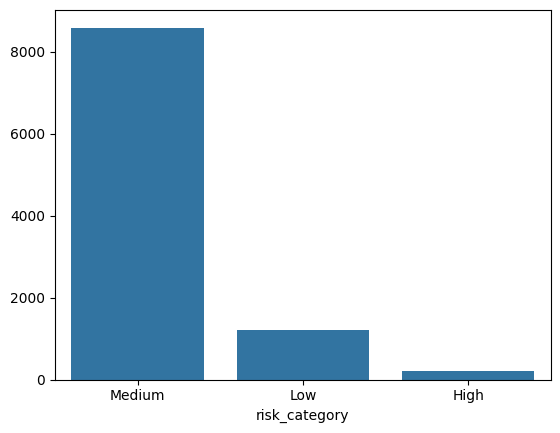

In [6]:
sns.barplot(x=df['risk_category'].value_counts().index, y=df['risk_category'].value_counts().values)

In [7]:
from sklearn.preprocessing import LabelEncoder

label_column = 'risk_category'
label_encoder = LabelEncoder()
label_encoder.fit(df[label_column])
labels = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
df[label_column] = label_encoder.transform(df[label_column])
labels

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

In [8]:
string_columns = df.select_dtypes(include=['str']).columns

df = pd.get_dummies(df, columns=string_columns, drop_first=True)
bool_columns = df.select_dtypes(include=['bool']).columns
df[bool_columns] = df[bool_columns].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   daily_travel_time              8876 non-null   float64
 1   nearby_industries              9205 non-null   float64
 2   home_air_quality               10000 non-null  float64
 3   smoker_in_household            10000 non-null  int64  
 4   noise_pollution_level          10000 non-null  float64
 5   use_of_air_purifiers           10000 non-null  int64  
 6   years_in_location              9480 non-null   float64
 7   pollution_exposure_score       10000 non-null  float64
 8   risk_category                  10000 non-null  int64  
 9   vehicle_ownership_Public Only  10000 non-null  int64  
 10  vehicle_ownership_Two-wheeler  10000 non-null  int64  
 11  location_type_Semi-Urban       10000 non-null  int64  
 12  location_type_Urban            10000 non-null  int64  
 13

<Axes: >

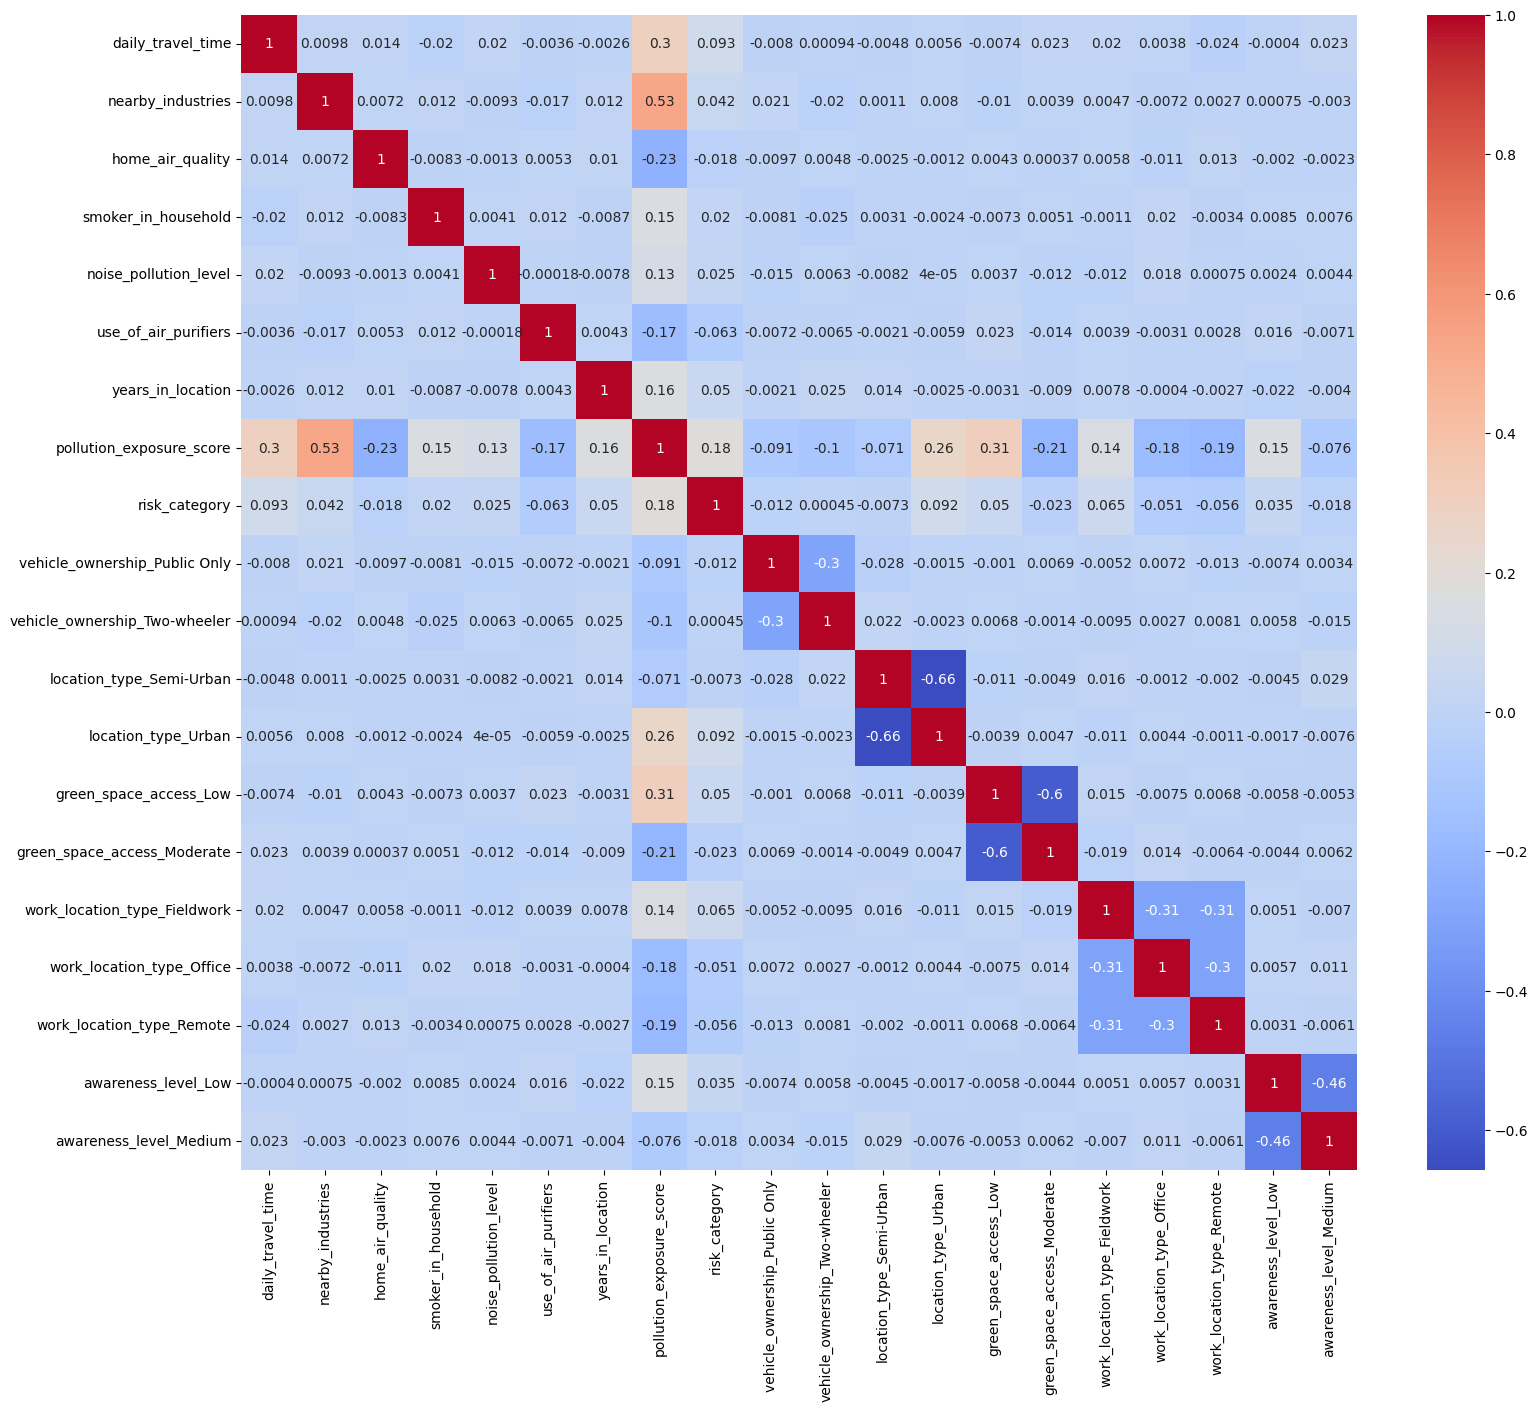

In [9]:
plt.figure(figsize=(18, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

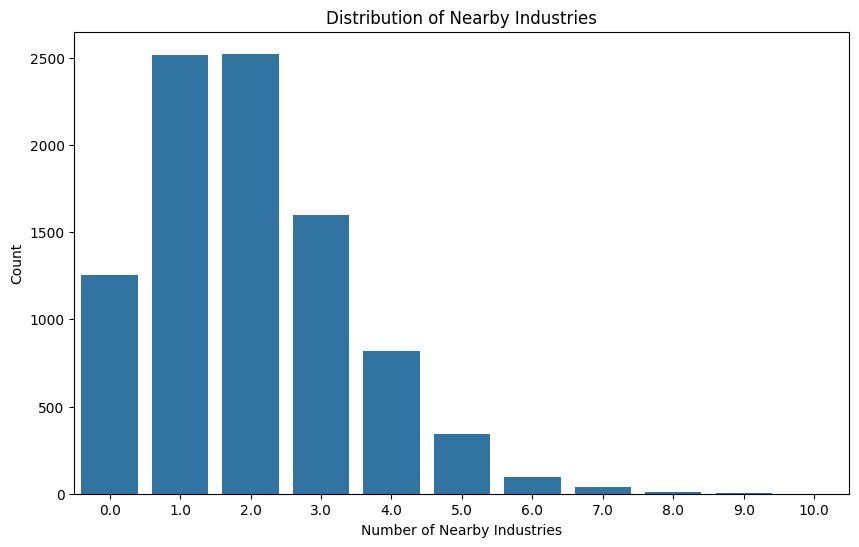

In [10]:
a = df['nearby_industries'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=a.index, y=a.values)
plt.xlabel('Number of Nearby Industries')
plt.ylabel('Count')
plt.title('Distribution of Nearby Industries')
plt.show()

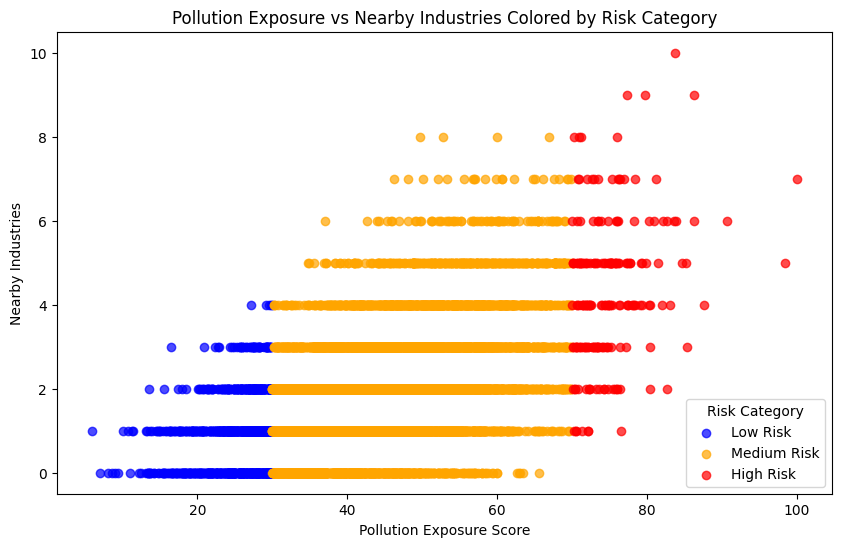

In [11]:
plt.figure(figsize=(10, 6))
low_risk = df[df['risk_category'] == labels['Low']]
medium_risk = df[df['risk_category'] == labels['Medium']]
high_risk = df[df['risk_category'] == labels['High']]
plt.scatter(low_risk['pollution_exposure_score'], low_risk['nearby_industries'], c='blue', label='Low Risk', alpha=0.7)
plt.scatter(medium_risk['pollution_exposure_score'], medium_risk['nearby_industries'], c='orange', label='Medium Risk', alpha=0.7)
plt.scatter(high_risk['pollution_exposure_score'], high_risk['nearby_industries'], c='red', label='High Risk', alpha=0.7)
plt.legend(title='Risk Category', loc='lower right')
plt.xlabel('Pollution Exposure Score')
plt.ylabel('Nearby Industries')
plt.title('Pollution Exposure vs Nearby Industries Colored by Risk Category')
plt.show()

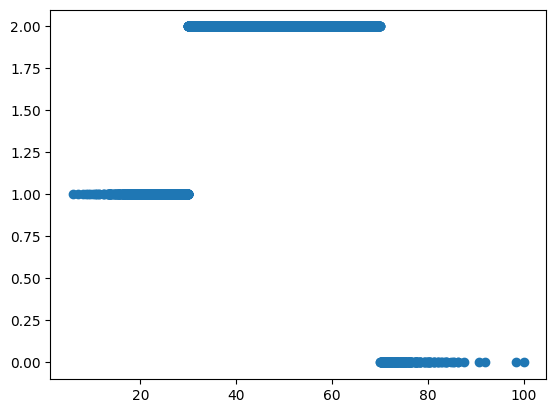

In [12]:
plt.scatter(df['pollution_exposure_score'], df['risk_category'])

In [13]:
from dataclasses import dataclass
from typing import Any


@dataclass
class ModelEvaluationResult:
    model: Any
    mse: float
    confusion_matrix: np.ndarray
    r2: float
    roc: float
    class_1_precision: float
    class_1_recall: float
    class_1_f1: float
    class_1_support: int
    class_2_precision: float
    class_2_recall: float
    class_2_f1: float
    class_2_support: int
    class_3_precision: float
    class_3_recall: float
    class_3_f1: float
    class_3_support: int


In [14]:
from sklearn.metrics import classification_report, mean_squared_error, confusion_matrix, roc_auc_score, r2_score

def fit_and_evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    class_1_precision = report['0']['precision']
    class_1_recall = report['0']['recall']
    class_1_f1 = report['0']['f1-score']
    class_1_support = report['0']['support']
    class_2_precision = report['1']['precision']
    class_2_recall = report['1']['recall']
    class_2_f1 = report['1']['f1-score']
    class_2_support = report['1']['support']
    class_3_precision = report['2']['precision']
    class_3_recall = report['2']['recall']
    class_3_f1 = report['2']['f1-score']
    class_3_support = report['2']['support']
    _confusion_matrix = confusion_matrix(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    roc = 0 # roc_auc_score(y_test, y_pred)

    return ModelEvaluationResult(
        model=model,
        mse=mse,
        confusion_matrix=_confusion_matrix,
        r2=r2,
        roc=roc,
        class_1_precision=class_1_precision,
        class_1_recall=class_1_recall,
        class_1_f1=class_1_f1,
        class_1_support=class_1_support,
        class_2_precision=class_2_precision,
        class_2_recall=class_2_recall,
        class_2_f1=class_2_f1,
        class_2_support=class_2_support,
        class_3_precision=class_3_precision,
        class_3_recall=class_3_recall,
        class_3_f1=class_3_f1,
        class_3_support=class_3_support
    )

In [15]:
from dataclasses import asdict
from sklearn.impute import KNNImputer
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.base import clone


class ModelTester:
    def __init__(self, X, y, test_size=0.2, random_state=42):
        self.results = []
        self.X = X
        self.y = y
        self.test_size = test_size
        self.random_state = random_state
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=self.test_size, random_state=self.random_state, stratify=self.y
        )

    def resample_data(self, method='oversample'):
        if method == 'oversample':
            # make all classes have the same number of samples as the majority class
            value_counts = self.y_train.value_counts()
            majority_class = value_counts.idxmax()
            minority_classes = value_counts.index[value_counts.index != majority_class]
            ratios = value_counts[majority_class] / value_counts[minority_classes]
            for minority_class in minority_classes:
                ratio = ratios[minority_class]
                n_samples = int(len(self.y_train) * ratio)
                X_minority = self.X_train[self.y_train == minority_class]
                y_minority = self.y_train[self.y_train == minority_class]
                X_resampled, y_resampled = resample(X_minority, y_minority, replace=True, n_samples=n_samples, random_state=self.random_state)
                self.X_train = pd.concat([self.X_train, X_resampled])
                self.y_train = pd.concat([self.y_train, y_resampled])
            print(f"After oversampling, class distribution:\n{self.y_train.value_counts()}")
            # minority_class = value_counts.idxmin()
            # ratio = value_counts[majority_class] / value_counts[minority_class]
            # n_samples = int(len(self.y_train) * ratio)
            self.X_train, self.y_train = resample(self.X_train, self.y_train, replace=True, random_state=self.random_state)
        elif method == 'undersample':
            df = pd.concat([self.X_train, self.y_train], axis=1)
            value_counts = self.y_train.value_counts()
            assert len(value_counts) == 2, "Undersampling only works for binary classification"
            majority_class = value_counts.idxmax()
            minority_class = value_counts.idxmin()
            majority_df = df[df[self.y_train.name] == majority_class]
            minority_df = df[df[self.y_train.name] == minority_class]
            majority_df_downsampled = majority_df.sample(n=len(minority_df), random_state=self.random_state)
            df_downsampled = pd.concat([majority_df_downsampled, minority_df])
            self.X_train = df_downsampled.drop(columns=[self.y_train.name])
            self.y_train = df_downsampled[self.y_train.name]
        elif method == 'hybrid':
            # first undersample the majority class, then oversample the minority classes to match the new majority class size
            df = pd.concat([self.X_train, self.y_train], axis=1)
            value_counts = self.y_train.value_counts()
            majority_class = value_counts.idxmax()
            minority_classes = value_counts.index[value_counts.index != majority_class]
            # undersample the majority class
            majority_df = df[df[self.y_train.name] == majority_class]
            minority_df = df[df[self.y_train.name] == minority_class]
            ratio = value_counts[majority_class] / value_counts[minority_classes].min()
            majority_df_downsampled = majority_df.sample(n=int(len(minority_df) * 0.5 * ratio), random_state=self.random_state)
            df_downsampled = pd.concat([majority_df_downsampled, minority_df])
            self.X_train = df_downsampled.drop(columns=[self.y_train.name])
            self.y_train = df_downsampled[self.y_train.name]
            # oversample the minority classes to match the new majority class size
            value_counts = self.y_train.value_counts()
            majority_class = value_counts.idxmax()
            minority_classes = value_counts.index[value_counts.index != majority_class]
            ratios = value_counts[majority_class] / value_counts[minority_classes]
            for minority_class in minority_classes:
                ratio = ratios[minority_class]
                n_samples = int(len(self.y_train) * ratio)
                X_minority = self.X_train[self.y_train == minority_class]
                y_minority = self.y_train[self.y_train == minority_class]
                # concatenate the oversampled minority class with the rest of the data
                self.X_train = pd.concat([self.X_train] + [X_minority] * len(minority_classes))
                self.y_train = pd.concat([self.y_train] + [y_minority] * len(minority_classes))
        else:
            raise ValueError("Method must be 'oversample' or 'undersample'")

    def _oversample(self, X, y):
        value_counts = y.value_counts()
        majority_class = value_counts.idxmax()
        minority_classes = value_counts.index[value_counts.index != majority_class]
        ratios = value_counts[majority_class] / value_counts[minority_classes]
        for minority_class in minority_classes:
            ratio = ratios[minority_class]
            n_samples = int(len(y) * ratio)
            X_minority = X[y == minority_class]
            y_minority = y[y == minority_class]
            X_resampled, y_resampled = resample(X_minority, y_minority, replace=True, n_samples=n_samples, random_state=self.random_state)
            X = pd.concat([X, X_resampled])
            y = pd.concat([y, y_resampled])
        return X, y

    def _undersample(self, X, y, target_size=None):
        df = pd.concat([X, y], axis=1)
        value_counts = y.value_counts()
        majority_class = value_counts.idxmax()
        minority_class = value_counts.idxmin()
        majority_df = df[df[y.name] == majority_class]
        minority_df = df[df[y.name] == minority_class]
        if target_size is not None:
            majority_df_downsampled = majority_df.sample(n=target_size, random_state=self.random_state)
        else:
            majority_df_downsampled = majority_df.sample(n=len(minority_df), random_state=self.random_state)
        df_downsampled = pd.concat([majority_df_downsampled, minority_df])
        X_downsampled = df_downsampled.drop(columns=[y.name])
        y_downsampled = df_downsampled[y.name]
        return X_downsampled, y_downsampled

    def test_model(self, model, k_fold=False, oversample=False, undersample=False, class_weight=None):
        if class_weight:
            if hasattr(model, 'class_weight'):
                value_counts = self.y_train.value_counts()
                classes = np.unique(self.y_train)
                weights = compute_class_weight(class_weight='balanced', classes=classes, y=self.y_train)
                cw = dict(zip(classes, weights))
                model.set_params(class_weight=cw)

        if k_fold:
            splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
            X_data = self.X_train
            y_data = self.y_train
            for train_index, test_index in splitter.split(X_data, y_data):
                imputer = KNNImputer(n_neighbors=5)
                X_train_kf, X_test_kf = X_data.iloc[train_index], X_data.iloc[test_index]
                y_train_kf, y_test_kf = y_data.iloc[train_index], y_data.iloc[test_index]

                X_train_kf = imputer.fit_transform(X_train_kf)
                X_test_kf = imputer.transform(X_test_kf)

                if oversample:
                    X_train_kf, y_train_kf = self._oversample_fold(X_train_kf, y_train_kf)
                elif undersample:
                    X_train_kf, y_train_kf = self._undersample(X_train_kf, y_train_kf, target_size=int(len(y_train_kf) / 2))

                result = fit_and_evaluate_model(clone(model), X_train_kf, y_train_kf, X_test_kf, y_test_kf)
                self.results.append(result)
        else:
            if oversample:
                X_train, y_train = self._oversample(self.X_train, self.y_train)
            elif undersample:
                X_train, y_train = self._undersample(self.X_train, self.y_train, target_size=int(len(self.y_train) / 2))
            else:
                X_train, y_train = self.X_train, self.y_train

            result = fit_and_evaluate_model(model, X_train, y_train, self.X_test, self.y_test)
            self.results.append(result)

    def get_results_dataframe(self):
        results_df = pd.DataFrame([asdict(result) for result in self.results])
        return results_df


In [16]:
from pprint import pprint

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from dataclasses import asdict

models = [
    DecisionTreeClassifier(random_state=42),
    Perceptron(random_state=42, max_iter=1_000, penalty='l2', alpha=0.01, eta0=0.1),
    RandomForestClassifier(random_state=42),
    LogisticRegression(random_state=42, max_iter=1_000),
    LinearSVC(random_state=42, max_iter=1_000),
    GaussianNB(),
    AdaBoostClassifier(random_state=42),
    MLPClassifier(random_state=42, max_iter=1_000, hidden_layer_sizes=(100,), alpha=0.0001, learning_rate_init=0.001)
]
X, y = df.drop(columns=['risk_category', 'pollution_exposure_score']), df['risk_category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

results = {}
for model in models:
    result = fit_and_evaluate_model(model, X_train, y_train, X_test, y_test)
    # pprint(result)
    # print("\n" + "="*80 + "\n")
    results[model.__class__.__name__] = result

# tester = ModelTester(X, y)
# tester.resample_data(method='undersample')
# for model in models:
#     tester.test_model(model, class_weight=False)
# results_df = tester.get_results_dataframe()
results_df = pd.DataFrame([asdict(result) for result in results.values()])
results_df.sort_values('r2', ascending=False)

/home/rafael-albuquerque/repos/ciencia_de_dados/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,mse,confusion_matrix,r2,roc,class_1_precision,class_1_recall,class_1_f1,class_1_support,class_2_precision,class_2_recall,class_2_f1,class_2_support,class_3_precision,class_3_recall,class_3_f1,class_3_support
3,"LogisticRegression(max_iter=1000, random_state...",0.1190,"[[20, 0, 23], [0, 145, 95], [2, 43, 1672]]",0.336792,0,0.909091,0.465116,0.615385,43.0,0.771277,0.604167,0.677570,240.0,0.934078,0.973791,0.953522,1717.0
7,"MLPClassifier(max_iter=1000, random_state=42)",0.1315,"[[19, 0, 24], [0, 119, 121], [6, 22, 1689]]",0.267128,0,0.760000,0.441860,0.558824,43.0,0.843972,0.495833,0.624672,240.0,0.920938,0.983692,0.951281,1717.0
5,GaussianNB(),0.1570,"[[20, 0, 23], [0, 131, 109], [9, 77, 1631]]",0.125012,0,0.689655,0.465116,0.555556,43.0,0.629808,0.545833,0.584821,240.0,0.925128,0.949913,0.937356,1717.0
4,LinearSVC(random_state=42),0.1645,"[[0, 0, 43], [0, 96, 144], [0, 13, 1704]]",0.083213,0,0.000000,0.000000,0.000000,43.0,0.880734,0.400000,0.550143,240.0,0.901111,0.992429,0.944568,1717.0
2,"(DecisionTreeClassifier(max_features='sqrt', r...",0.1650,"[[3, 0, 40], [0, 86, 154], [0, 16, 1701]]",0.080426,0,1.000000,0.069767,0.130435,43.0,0.843137,0.358333,0.502924,240.0,0.897625,0.990681,0.941860,1717.0
6,"(DecisionTreeClassifier(max_depth=1, random_st...",0.1715,"[[9, 0, 34], [0, 53, 187], [3, 8, 1706]]",0.044201,0,0.750000,0.209302,0.327273,43.0,0.868852,0.220833,0.352159,240.0,0.885314,0.993593,0.936334,1717.0
0,DecisionTreeClassifier(random_state=42),0.2555,"[[14, 0, 29], [0, 117, 123], [34, 136, 1547]]",-0.423946,0,0.291667,0.325581,0.307692,43.0,0.462451,0.487500,0.474645,240.0,0.910536,0.900990,0.905738,1717.0
1,"Perceptron(alpha=0.01, eta0=0.1, penalty='l2',...",0.3005,"[[0, 0, 43], [0, 97, 143], [0, 286, 1431]]",-0.674738,0,0.000000,0.000000,0.000000,43.0,0.253264,0.404167,0.311396,240.0,0.884972,0.833430,0.858428,1717.0


In [17]:
import tqdm

balanced_tester = ModelTester(X, y)
# balanced_tester.resample_data(method='oversample')
for model in tqdm.tqdm(models):
    tqdm.tqdm.write(f"Testing model {model.__class__.__name__}")
    balanced_tester.test_model(model, k_fold=True)
balanced_results_df = balanced_tester.get_results_dataframe()
balanced_results_df.sort_values('r2', ascending=False)

  0%|          | 0/8 [00:00<?, ?it/s]

Testing model DecisionTreeClassifier


 12%|█▎        | 1/8 [00:02<00:20,  2.87s/it]

Testing model Perceptron


 25%|██▌       | 2/8 [00:05<00:16,  2.81s/it]

...

Testing model AdaBoostClassifier


 88%|████████▊ | 7/8 [00:30<00:04,  4.23s/it]

Testing model MLPClassifier


100%|██████████| 8/8 [00:37<00:00,  4.75s/it]


,model,mse,confusion_matrix,r2,roc,class_1_precision,class_1_recall,class_1_f1,class_1_support,class_2_precision,class_2_recall,class_2_f1,class_2_support,class_3_precision,class_3_recall,class_3_f1,class_3_support
17,"LogisticRegression(max_iter=1000, random_state...",0.119375,"[[17, 0, 17], [0, 117, 75], [3, 36, 1335]]",0.331584,0,0.850000,0.500000,0.629630,34.0,0.764706,0.609375,0.678261,192.0,0.935529,0.971616,0.953231,1374.0
19,"LogisticRegression(max_iter=1000, random_state...",0.121875,"[[16, 0, 19], [0, 115, 76], [3, 31, 1340]]",0.323913,0,0.842105,0.457143,0.592593,35.0,0.787671,0.602094,0.682493,191.0,0.933798,0.975255,0.954076,1374.0
18,"LogisticRegression(max_iter=1000, random_state...",0.135625,"[[14, 0, 21], [0, 105, 86], [3, 35, 1336]]",0.247636,0,0.823529,0.400000,0.538462,35.0,0.750000,0.549738,0.634441,191.0,0.925849,0.972344,0.948527,1374.0
15,"LogisticRegression(max_iter=1000, random_state...",0.141250,"[[10, 0, 24], [0, 120, 72], [5, 38, 1331]]",0.209099,0,0.666667,0.294118,0.408163,34.0,0.759494,0.625000,0.685714,192.0,0.932726,0.968705,0.950375,1374.0
37,"MLPClassifier(max_iter=1000, random_state=42)",0.141875,"[[8, 0, 26], [0, 101, 91], [2, 24, 1348]]",0.205599,0,0.800000,0.235294,0.363636,34.0,0.808000,0.526042,0.637224,192.0,0.920137,0.981077,0.949630,1374.0
16,"LogisticRegression(max_iter=1000, random_state...",0.150000,"[[14, 0, 20], [0, 110, 82], [11, 34, 1329]]",0.160105,0,0.560000,0.411765,0.474576,34.0,0.763889,0.572917,0.654762,192.0,0.928721,0.967249,0.947594,1374.0
35,"MLPClassifier(max_iter=1000, random_state=42)",0.156875,"[[4, 0, 30], [0, 125, 67], [5, 44, 1325]]",0.121610,0,0.444444,0.117647,0.186047,34.0,0.739645,0.651042,0.692521,192.0,0.931786,0.964338,0.947783,1374.0
38,"MLPClassifier(max_iter=1000, random_state=42)",0.158750,"[[4, 0, 31], [0, 112, 79], [2, 43, 1329]]",0.119353,0,0.666667,0.114286,0.195122,35.0,0.722581,0.586387,0.647399,191.0,0.923558,0.967249,0.944899,1374.0
39,"MLPClassifier(max_iter=1000, random_state=42)",0.161875,"[[11, 0, 24], [0, 124, 67], [13, 44, 1317]]",0.102018,0,0.458333,0.314286,0.372881,35.0,0.738095,0.649215,0.690808,191.0,0.935369,0.958515,0.946801,1374.0
20,LinearSVC(random_state=42),0.162500,"[[0, 0, 34], [0, 82, 110], [0, 14, 1360]]",0.090114,0,0.000000,0.000000,0.000000,34.0,0.854167,0.427083,0.569444,192.0,0.904255,0.989811,0.945101,1374.0


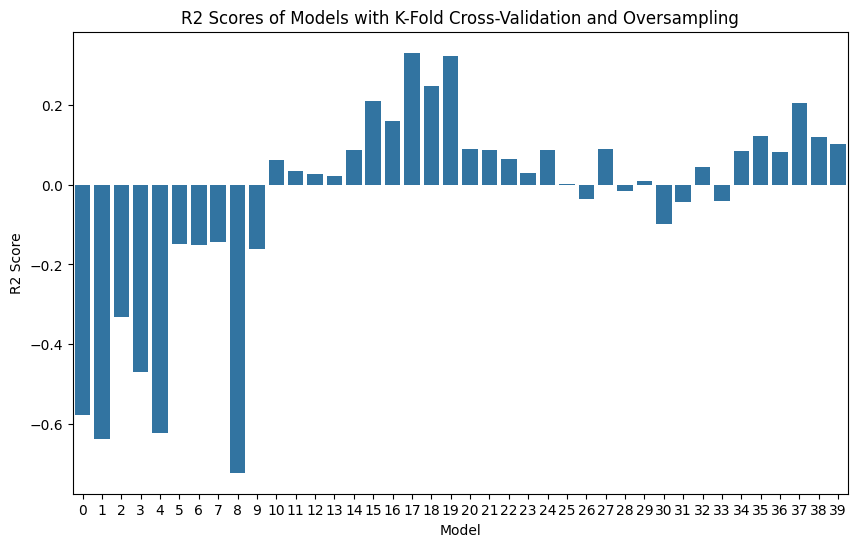

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x=balanced_results_df.index, y=balanced_results_df['r2'])
plt.title('R2 Scores of Models with K-Fold Cross-Validation and Oversampling')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.show()

Best model: LogisticRegression with R2=0.3316 at index 17


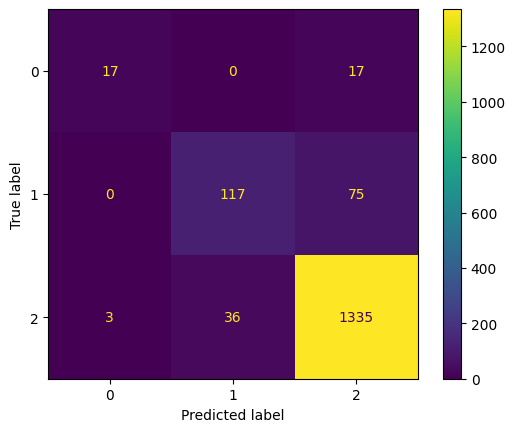

In [19]:
best_r2 = balanced_results_df['r2'].idxmax()
print(f"Best model: {balanced_results_df.iloc[best_r2]['model'].__class__.__name__} with R2={balanced_results_df.iloc[best_r2]['r2']:.4f} at index {best_r2}")
cm = ConfusionMatrixDisplay(confusion_matrix=balanced_results_df.iloc[best_r2]['confusion_matrix'])
cm.plot()

In [20]:
pprint(balanced_results_df.iloc[best_r2].to_dict())

{'class_1_f1': 0.6296296296296297,
 'class_1_precision': 0.85,
 'class_1_recall': 0.5,
 'class_1_support': 34.0,
 'class_2_f1': 0.6782608695652174,
 'class_2_precision': 0.7647058823529411,
 'class_2_recall': 0.609375,
 'class_2_support': 192.0,
 'class_3_f1': 0.9532309889325241,
 'class_3_precision': 0.9355290819901892,
 'class_3_recall': 0.9716157205240175,
 'class_3_support': 1374.0,
 'confusion_matrix': array([[  17,    0,   17],
       [   0,  117,   75],
       [   3,   36, 1335]]),
 'model': LogisticRegression(max_iter=1000, random_state=42),
 'mse': 0.119375,
 'r2': 0.331583552055993,
 'roc': 0}


# Regressão

In [21]:
# df = pd.read_csv('urban_lifestyle_impact_dataset.csv')

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor


models = [
    LinearRegression(),
    RandomForestRegressor(random_state=42),
    DecisionTreeRegressor(random_state=42),
    AdaBoostRegressor(random_state=42),
    MLPRegressor(random_state=42, max_iter=1_000, hidden_layer_sizes=(100, 50), alpha=0.01, learning_rate_init=0.1)
]

X, y = df.drop(columns=['risk_category', 'pollution_exposure_score']), df['pollution_exposure_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

for model in models:
    print(f"Testing model {model.__class__.__name__}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Model: {model.__class__.__name__}, MSE: {mse:.4f}, R2: {r2:.4f}\n\n")


Testing model LinearRegression
Model: LinearRegression, MSE: 29.4130, R2: 0.8007


Testing model RandomForestRegressor
Model: RandomForestRegressor, MSE: 37.1039, R2: 0.7486


Testing model DecisionTreeRegressor
Model: DecisionTreeRegressor, MSE: 80.1800, R2: 0.4566


Testing model AdaBoostRegressor
Model: AdaBoostRegressor, MSE: 49.1806, R2: 0.6667


Testing model MLPRegressor
Model: MLPRegressor, MSE: 30.2278, R2: 0.7952


